Supply Chain & Inventory Analytics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

STEP-BY-STEP PYTHON IMPLEMENTATION

In [6]:
#Import Dataset
df = pd.read_csv("supply_chain_raw_data.csv")

df.head()

,Order_ID,Product,Supplier,Warehouse,Order_Date,Delivery_Date,Quantity,Stock_Level,Shipping_Cost,Order_Status,Customer_Region,Order_Accuracy
0,1,Printer,FastLogix,Hyderabad,2025-08-13,2025-08-23,50,401,141.14,Delayed,East Dianaville,1
1,2,Router,SupplyHub,Hyderabad,2025-11-11,2025-11-15,18,240,125.61,In Transit,Mercerbury,1
2,3,Tablet,Prime Vendors,Mumbai,2025-07-08,2025-07-15,70,423,580.19,In Transit,New Jasmine,1
3,4,Laptop,TechSource,Bangalore,2025-04-18,2025-04-22,31,354,672.40,Delivered,South Leslie,1
4,5,Laptop,Prime Vendors,Mumbai,2025-03-24,2025-04-01,29,343,446.27,In Transit,Robertmouth,1


In [7]:
#Basic Data Inspection
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         200 non-null    int64  
 1   Product          200 non-null    object 
 2   Supplier         200 non-null    object 
 3   Warehouse        200 non-null    object 
 4   Order_Date       200 non-null    object 
 5   Delivery_Date    200 non-null    object 
 6   Quantity         200 non-null    int64  
 7   Stock_Level      200 non-null    int64  
 8   Shipping_Cost    200 non-null    float64
 9   Order_Status     200 non-null    object 
 10  Customer_Region  200 non-null    object 
 11  Order_Accuracy   200 non-null    int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 18.9+ KB


Order_ID           0
Product            0
Supplier           0
Warehouse          0
Order_Date         0
Delivery_Date      0
Quantity           0
Stock_Level        0
Shipping_Cost      0
Order_Status       0
Customer_Region    0
Order_Accuracy     0
dtype: int64

Data Cleaning

In [9]:
#Convert Dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])

Create New Features

In [12]:
#Delivery Time
df['Delivery_Time'] = (
    df['Delivery_Date'] - df['Order_Date']
).dt.days

In [13]:
#Delayed Shipment Flag
df['Delayed'] = df['Delivery_Time'].apply(
    lambda x: 1 if x > 5 else 0
)

Exploratory Data Analysis

In [16]:
#Delayed Shipments
df['Delayed'].value_counts()

Delayed
1    115
0     85
Name: count, dtype: int64

In [17]:
#Top Suppliers
df.groupby('Supplier')['Order_ID'].count() \
.sort_values(ascending=False)

Supplier
TechSource         50
SupplyHub          46
Prime Vendors      39
FastLogix          33
Global Supplies    32
Name: Order_ID, dtype: int64

In [18]:
#Warehouse Performance
df.groupby('Warehouse')['Delivery_Time'].mean()

Warehouse
Bangalore    5.512821
Chennai      6.159091
Delhi        6.289474
Hyderabad    6.428571
Mumbai       6.431818
Name: Delivery_Time, dtype: float64

Data Visualization

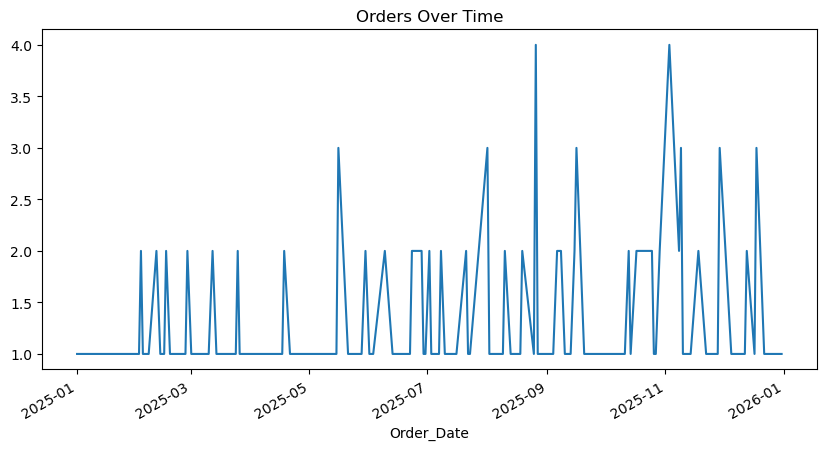

In [20]:
#Delivery Trend
plt.figure(figsize=(10,5))

df.groupby('Order_Date')['Order_ID'].count().plot()

plt.title("Orders Over Time")
plt.show()

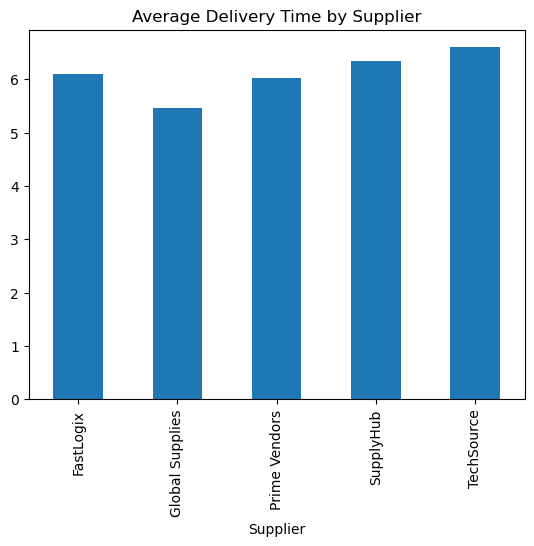

In [21]:
#Supplier Performance
supplier_perf = df.groupby('Supplier')['Delivery_Time'].mean()

supplier_perf.plot(kind='bar')

plt.title("Average Delivery Time by Supplier")
plt.show()

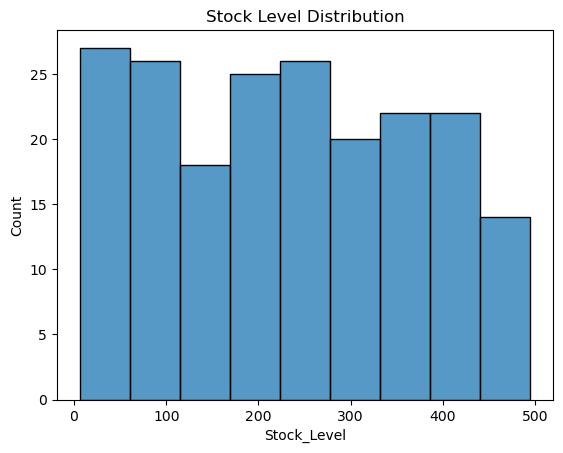

In [22]:
#Inventory Distribution
sns.histplot(df['Stock_Level'])

plt.title("Stock Level Distribution")
plt.show()

KPI Calculation

In [26]:
#Average Delivery Time
avg_delivery = df['Delivery_Time'].mean()

In [27]:
#Delay Percentage
delay_percent = (
    df['Delayed'].sum() / len(df)
) * 100

In [28]:
#Stock Availability
stock_available = (
    (df['Stock_Level'] > 0).sum() / len(df)
) * 100

SQL + Python Integration

In [30]:
#connecting to SQL server
import mysql.connector


host="127.0.0.1"
port=3306
username="root"
password="root"
database="supply_chain"

from sqlalchemy import create_engine
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")
print("Successfully connected")

Successfully connected


In [31]:
df.to_sql(
    'supply_chain',
    con=engine,
    if_exists='replace',
    index=False
)

200